In [165]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [166]:
uber_df=pd.read_csv('UberDataset.csv')

In [167]:
uber_df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [168]:
uber_df.tail()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site
1155,Totals,NaN,NaN,NaN,NaN,12204.7,NaN


In [169]:
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [170]:
uber_df.shape

(1156, 7)

DATA CLEANING 

In [171]:
uber_df[uber_df.duplicated()]

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
492,6/28/2016 23:34,6/28/2016 23:59,Business,Durham,Cary,9.9,Meeting


In [172]:
uber_df.drop_duplicates(inplace=True)

IMPUTATION OF MISSIING VALUE

In [173]:
uber_df.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [174]:
uber_df.drop(uber_df.index[-1],inplace=True )

In [175]:
uber_df.isnull().sum()

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

In [176]:
uber_df['PURPOSE'].fillna("Not mentioned",inplace=True)

In [177]:
uber_df.isnull().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

FORMATING 

In [178]:
uber_df.dtypes

START_DATE     object
END_DATE       object
CATEGORY       object
START          object
STOP           object
MILES         float64
PURPOSE        object
dtype: object

In [179]:
uber_df['START_DATE']=pd.to_datetime(uber_df['START_DATE'],errors='coerce')

In [180]:
uber_df['END_DATE']=pd.to_datetime(uber_df['END_DATE'],errors='coerce')

In [181]:
uber_df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not mentioned
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [182]:
uber_df.describe(include=['object'])

,CATEGORY,START,STOP,PURPOSE
count,1154,1154,1154,1154
unique,2,177,188,11
top,Business,Cary,Cary,Not mentioned
freq,1077,201,202,502


In [183]:
uber_df.describe()

,START_DATE,END_DATE,MILES
count,421,420,1154.000000
mean,2016-07-01 12:31:09.976247040,2016-07-01 12:11:10.142857216,10.567418
min,2016-01-01 21:11:00,2016-01-01 21:17:00,0.500000
25%,2016-04-01 13:43:00,2016-03-27 15:10:00,2.900000
50%,2016-07-04 18:23:00,2016-07-04 18:19:00,6.000000
75%,2016-10-10 17:22:00,2016-10-10 17:39:15,10.400000
max,2016-12-12 20:48:00,2016-12-12 20:57:00,310.300000
std,NaN,NaN,21.588452


In [184]:
from datetime import datetime
uber_df['DATE']=pd.DatetimeIndex(uber_df['START_DATE']).date
uber_df['TIME']=pd.DatetimeIndex(uber_df['START_DATE']).hour

In [185]:
uber_df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not mentioned,2016-01-02,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0


In [186]:
uber_df['DAYTIME']=pd.cut(x=uber_df['TIME'], bins=[0,10,15,19,24], labels=['Morning','Afternoon','Evening','Night'])

In [187]:
uber_df.isnull().sum()

START_DATE    733
END_DATE      734
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE         0
DATE          733
TIME          733
DAYTIME       740
dtype: int64

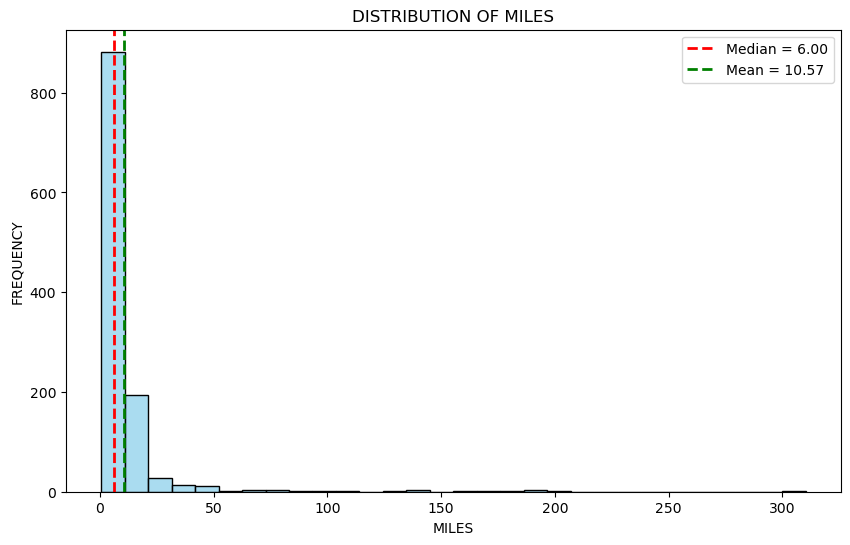

In [188]:
##data visualization 
plt.figure(figsize=(10,6))
median=uber_df['MILES'].median()
mean=uber_df['MILES'].mean()
sns.histplot(uber_df['MILES'] ,bins=30,color='skyblue',edgecolor='black',alpha=0.7)
plt.axvline(median,color='red',linewidth=2,linestyle='--',label=f"Median = {median:.2f}")
plt.axvline(mean,color='green',linewidth=2,linestyle='--',label=f"Mean = {mean:.2f}")
plt.xlabel('MILES')
plt.ylabel('FREQUENCY')
plt.title('DISTRIBUTION OF MILES')
plt.legend()
plt.show()

In [189]:
uber_df['START'].value_counts().head(10)

START
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Lahore               36
Durham               36
Raleigh              28
Kar?chi              27
Westpark Place       17
Name: count, dtype: int64

In [190]:
uber_df['START'] = uber_df['START'].replace('Kar?chi', 'Karachi')

In [191]:
uber_df['STOP'] = uber_df['STOP'].replace('Kar?chi', 'Karachi')

In [192]:
uber_df['START'].value_counts().head(10)

START
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Lahore               36
Durham               36
Karachi              31
Raleigh              28
Westpark Place       17
Name: count, dtype: int64

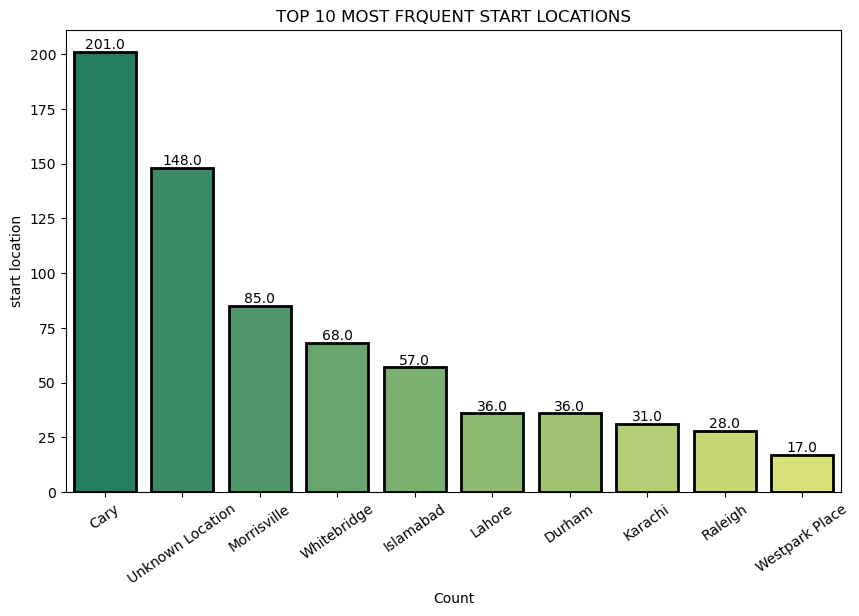

In [193]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(10,6))

ax=sns.countplot(x='START',order=pd.value_counts(uber_df['START']).iloc[:10].index,
               data= uber_df,
               palette='summer',
               edgecolor='black',linewidth=2)
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.xlabel('Count')
plt.xticks(rotation=35)
plt.ylabel('start location')
plt.title('TOP 10 MOST FRQUENT START LOCATIONS')
plt.show()

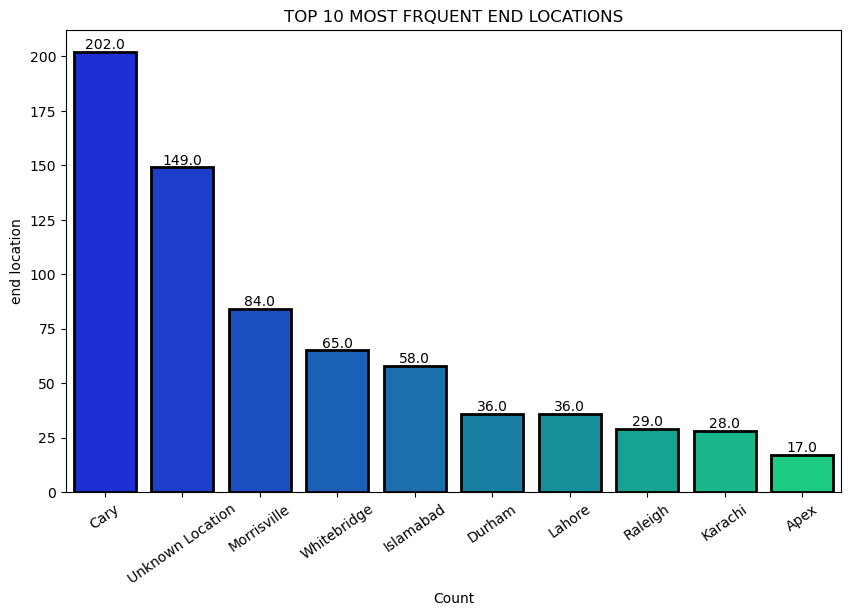

In [194]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(10,6))

ax=sns.countplot(x='STOP',order=pd.value_counts(uber_df['STOP']).iloc[:10].index,
               data= uber_df,
               palette='winter',
               edgecolor='black',linewidth=2)
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.xlabel('Count')
plt.xticks(rotation=35)
plt.ylabel('end location')
plt.title('TOP 10 MOST FRQUENT END LOCATIONS')
plt.show()

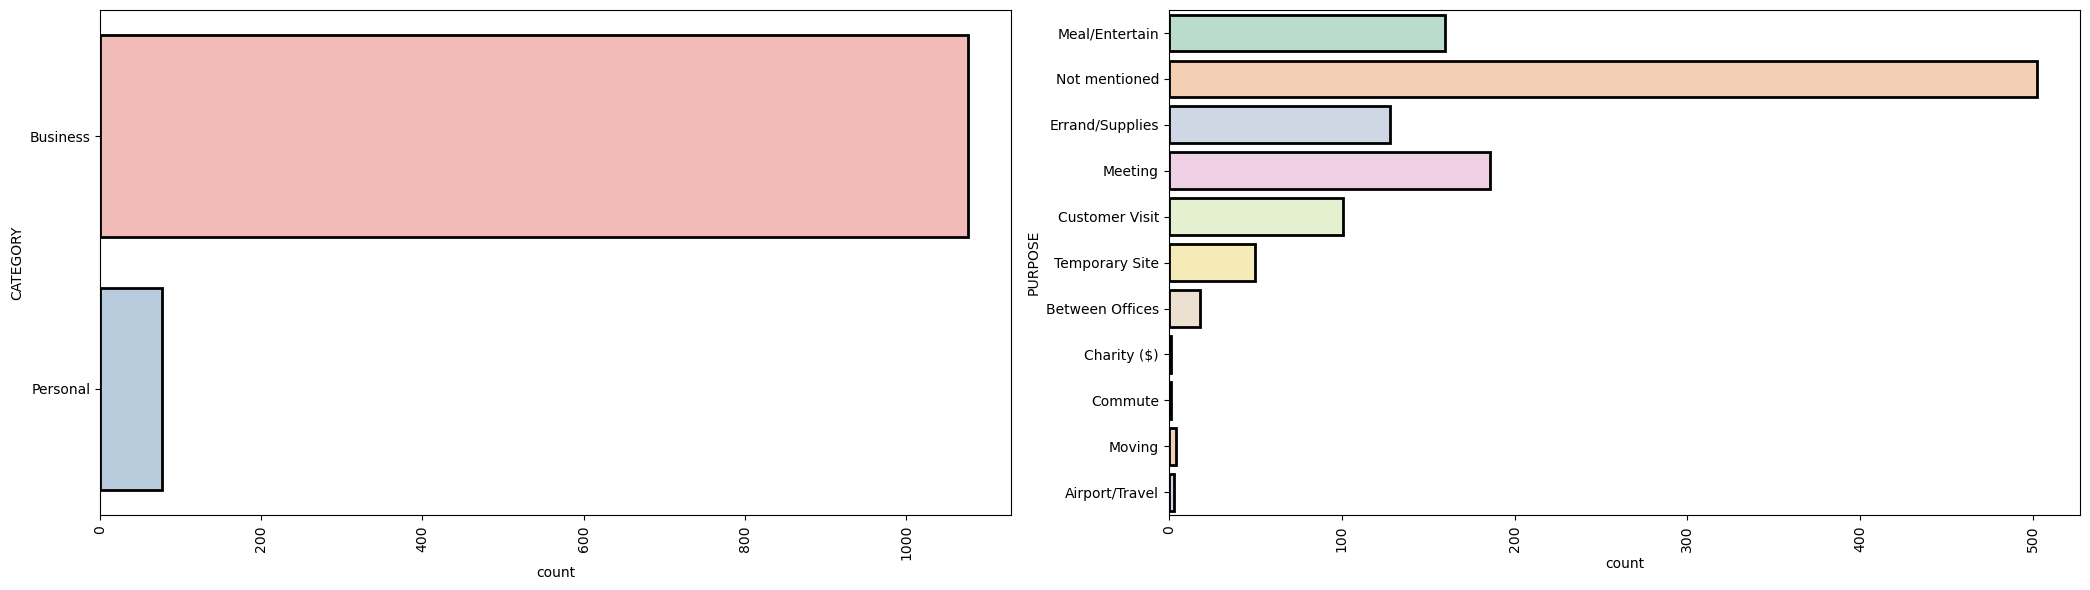

In [195]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(21,6))
plt.subplot(1,2,1)
sns.countplot(uber_df['CATEGORY'],palette='Pastel1',edgecolor='black',linewidth=2)
plt.xticks(rotation=90)

plt.subplot(1,2,2)
sns.countplot(uber_df['PURPOSE'],palette='Pastel2',edgecolor='black',linewidth=2)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


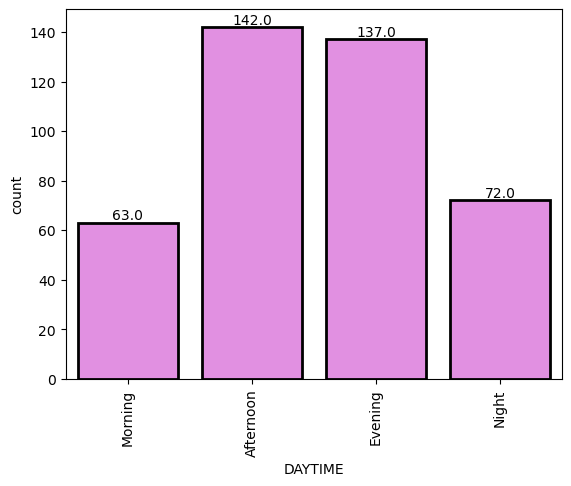

In [196]:
ax=sns.countplot(x=uber_df['DAYTIME'],color='violet',edgecolor='black',linewidth=2)
for p in ax.patches:
     ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.xticks(rotation=90)
plt.show()

In [197]:
uber_df.isnull().sum()

START_DATE    733
END_DATE      734
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE         0
DATE          733
TIME          733
DAYTIME       740
dtype: int64

In [198]:
uber_df['DAYTIME']=uber_df['DAYTIME'].ffill()


In [199]:
uber_df.isnull().sum()

START_DATE    733
END_DATE      734
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE         0
DATE          733
TIME          733
DAYTIME         0
dtype: int64

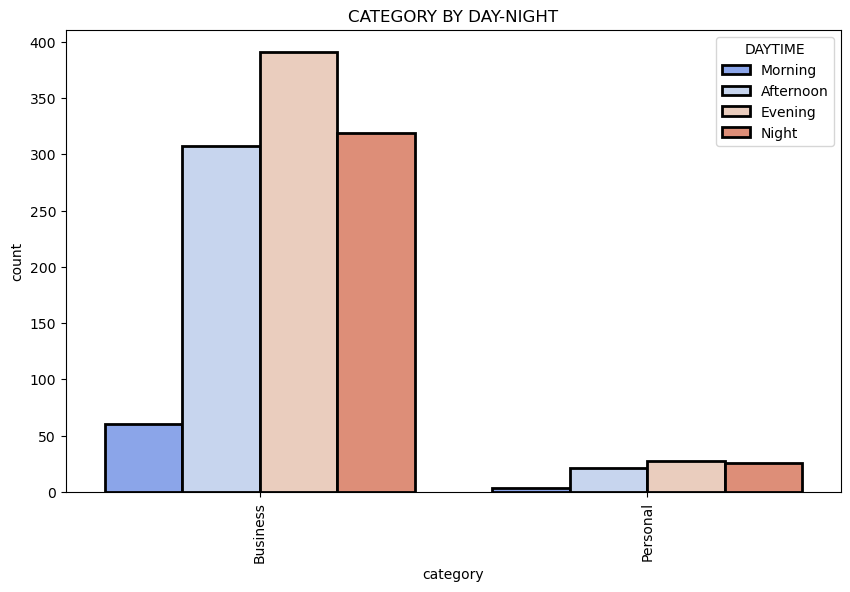

In [200]:
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='CATEGORY',hue='DAYTIME', palette='coolwarm',edgecolor='black',linewidth=2)
plt.xticks(rotation=90)
plt.title('CATEGORY BY DAY-NIGHT')
plt.xlabel('category')
plt.ylabel('count')
plt.show()

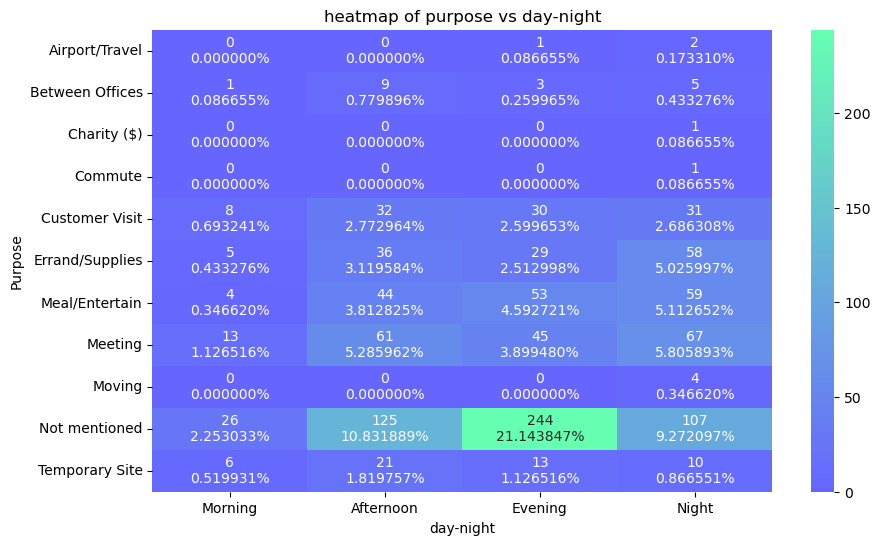

In [201]:
plt.figure(figsize=(10,6))
heatmap_data=uber_df.groupby(['PURPOSE','DAYTIME']).size().unstack()
total=heatmap_data.sum().sum()
sns.heatmap(heatmap_data,annot=heatmap_data.applymap(lambda x:f'{x}\n{x/total:%}'),cmap='winter',fmt='s',alpha=0.6)##annot will enter the values annot=false does not enter anyvalue,cmap- is colour of the map,cmap='YlGnBu' ,fmd is format of the map 
plt.title('heatmap of purpose vs day-night')
plt.xlabel('day-night')
plt.ylabel('Purpose')
plt.show()

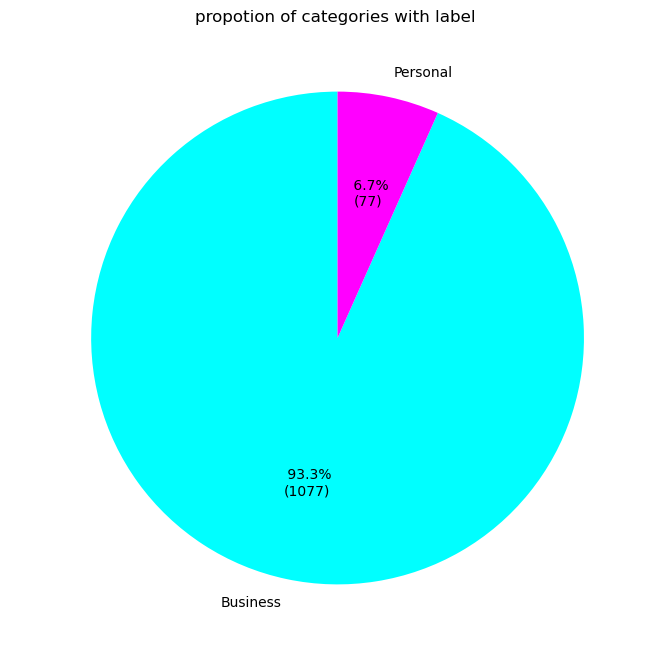

In [202]:
plt.figure(figsize=(8,8))
def autopct_with_counts(pct,values):
    total=sum(values)
    absolute=int(pct/100*total)
    return f'{pct: .1f}%\n({absolute})'

uber_df['CATEGORY'].value_counts().plot.pie(autopct= lambda pct:autopct_with_counts(pct,uber_df['CATEGORY'].value_counts()) ,startangle=90,cmap='cool')
plt.title('propotion of categories with label ')
plt.ylabel(' ')
plt.show()

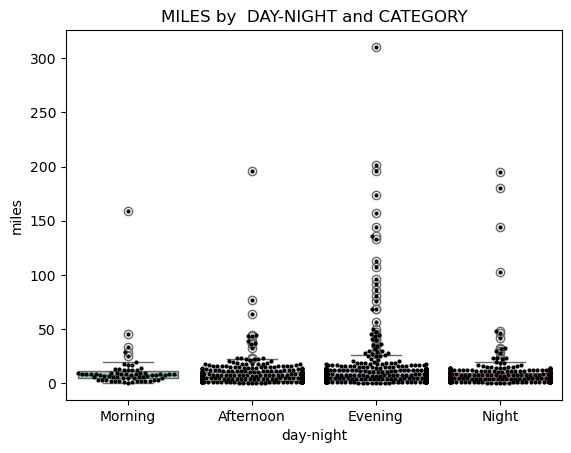

In [203]:
sns.boxplot(data=uber_df,x='DAYTIME',y='MILES',palette='Set3')
sns.swarmplot(data=uber_df,x='DAYTIME',y='MILES',color='black',size=3 )
plt.title('MILES by  DAY-NIGHT and CATEGORY')
plt.xlabel('day-night')
plt.ylabel('miles')
plt.show()

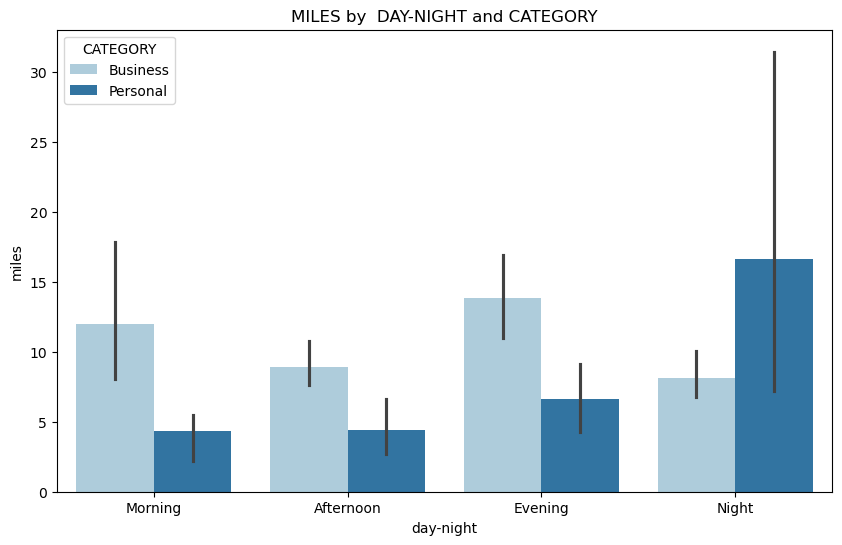

In [204]:
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='DAYTIME',y='MILES',hue='CATEGORY',palette='Paired')
plt.title('MILES by  DAY-NIGHT and CATEGORY')
plt.xlabel('day-night')
plt.ylabel('miles')
plt.show()

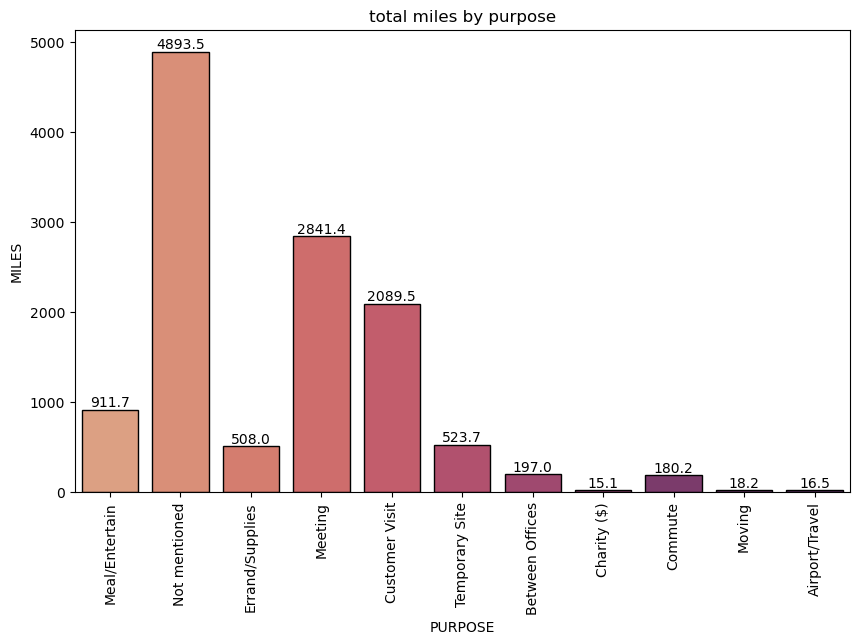

In [205]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=sum, ci=None, palette='flare',edgecolor='black')
for p in ax.patches:
     ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.xticks(rotation=90)
plt.title('total miles by purpose')
plt.show()

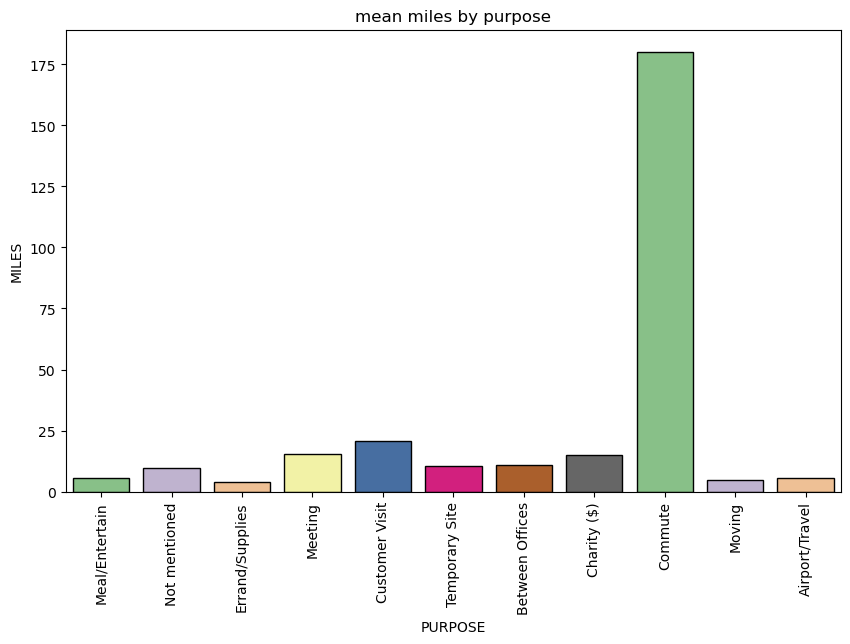

In [206]:
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=np.mean, ci=None, palette='Accent',edgecolor='black')   
plt.xticks(rotation=90)
plt.title('mean miles by purpose')
plt.show()

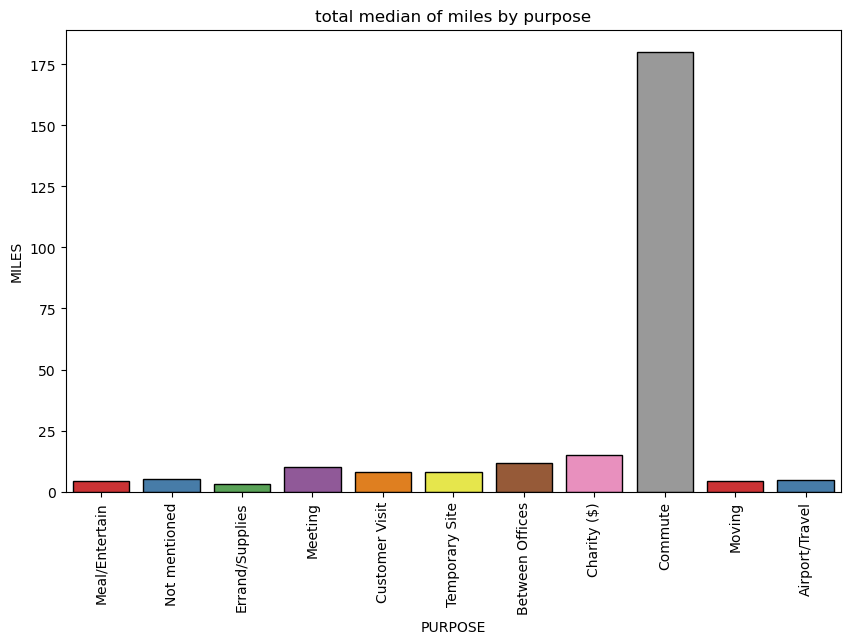

In [207]:
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,x='PURPOSE',y='MILES', estimator=np.median, ci=None, palette='Set1',edgecolor='black')
plt.xticks(rotation=90)
plt.title('total median of miles by purpose')
plt.show()

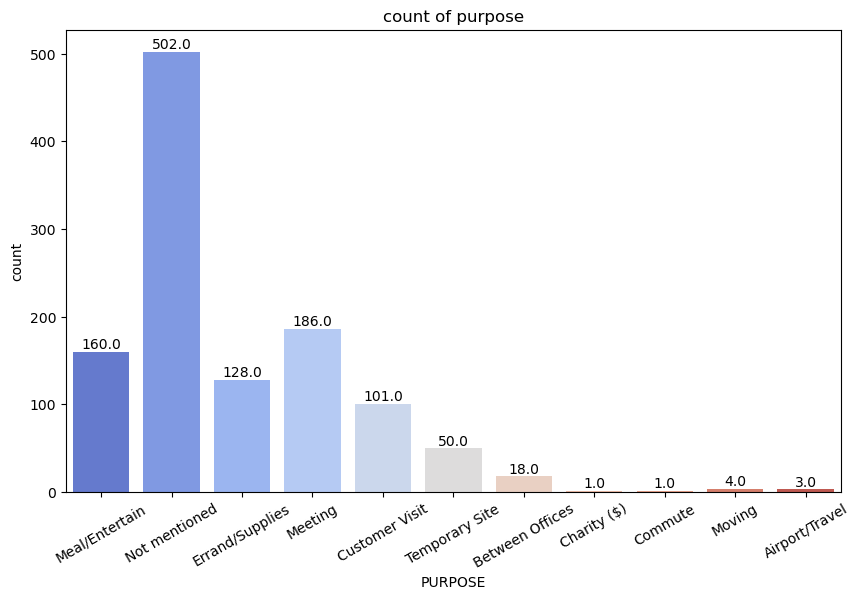

In [208]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=uber_df,x='PURPOSE' ,palette='coolwarm')
for p in ax.patches:
     ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.xticks(rotation=30)
plt.title('count of purpose')
plt.show()

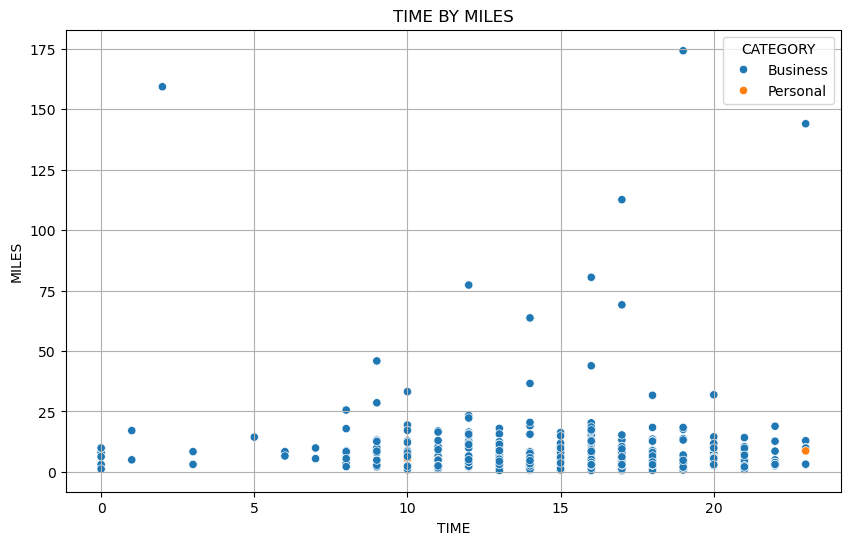

In [209]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=uber_df,x='TIME',y='MILES',hue='CATEGORY')
plt.title("TIME BY MILES")
plt.grid(True)
plt.show()

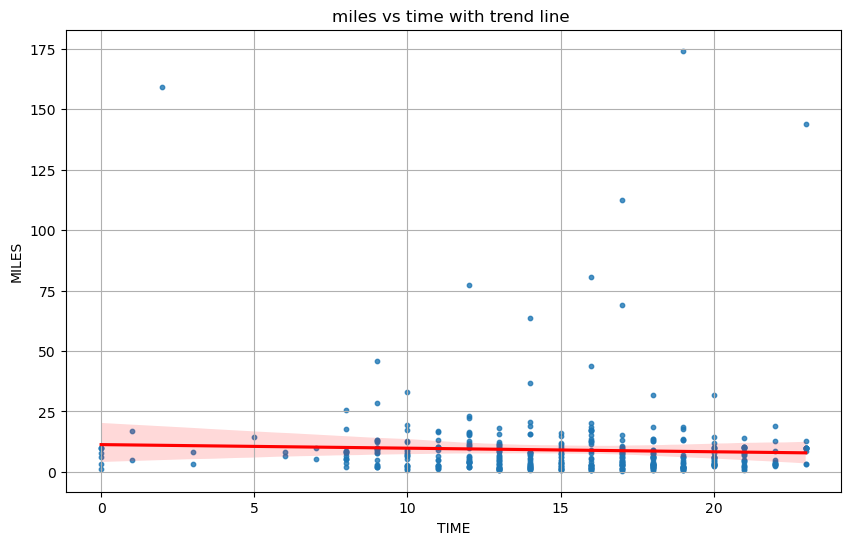

In [210]:
plt.figure(figsize=(10,6))
sns.regplot(data=uber_df,x='TIME',y='MILES', scatter_kws={'s':10},line_kws={'color':'red'})
plt.title("miles vs time with trend line ")
plt.grid(True)
plt.show()

___##Insights form all this analysis___:
The first step of data science is data collecting and data cleaning
i cleaned the dataset by checking the duplicated rows and coloums removed the duplicated rows 
i checked for the null values and imputed with apporpirate value :
                -->here only purpose column had null value imputed with common charcter
___In data preprocessing step___:
   --> i checked for the corrected data type for  all colums and start and end date was in object i
changed to pd.datetime format..
INSIGHTS
** columns:
     START_DATE	END_DATE	CATEGORY	START	STOP	MILES	PURPOSE


____DISTRIBUTION OF MILES_____:
 In the chart of distribution of miles the miles is distributed from 0 to 50 mostly 0 miles has highest frequency with above 800 the mean value is 10.57 and median value is 6.00 
    ---> from this chart we can get that the mean avarege frequecy of miles is 10m 

    
____TOP 10 MOST FREQUENT START LOCATIONS_____
   From this we can understand mostly 201 bookings are done in cary and 85 bookings done in morrisville 
   and very lowest booking is westpark place-- 17  if we could find the reason of lowest booking from westpark place we could imporve the booking satus by asking the feedback from customers and drivers ..

   
____TOP 10 MOST FREQUENT END LOCATIONS_____
  From this chart we can understand again cary stands first in end loaction also if we could give any discount on booking in cary we could get more bookings which would be more profitable accordingly here 
 from top 10 start location and end location most people preffered not to give location. so if we build the trust if they give a appropirate location ..or often location they booked we could give a discount which would force them to give a appropirate location not only discount on frequent booking we could tell them which time they can book so the price will be low this improve tranceperancy and customer priority and we could add rating system based on their travel 


____Most people used the uber ride for business purpose____

____Here we lack transperancy most people mentioned not to know their purpose of vist___


____Most of the ride is booked at afternoon--142 and evening 137__
  --->so we could imporve the speed of ride booking in afternoon and evening we could help customer to get their ride as fast as can 
  ---> to avoid the cacellation for whatever reason it might be 

 
_______Total Miles by Purpose (Bar Chart)___


* **"Not Mentioned"** accounts for the **highest total mileage (4893.5 miles)** by a very large margin.

  * This indicates that a significant portion of trips have **missing or unspecified purpose information**.
  * It suggests a **data quality issue** rather than a travel behavior.

* **Meeting** is the **most common recorded business purpose** with **2841.4 miles**.

  * This shows that meetings contribute substantially to total travel.

* **Customer Visit** is the second-largest recorded purpose with **2089.5 miles**.

  * Customer interactions are another major reason for business travel.

* **Meal/Entertain (911.7 miles)**, **Temporary Site (523.7 miles)**, and **Errand/Supplies (508 miles)** contribute a moderate amount of mileage.

* **Commute (180.2 miles)** and **Between Offices (197 miles)** account for relatively few miles.

* **Charity (15.1 miles)**, **Moving (18.2 miles)**, and **Airport/Travel (16.5 miles)** contribute very little to the total mileage, indicating these activities are rare.

_____Time vs Miles (Scatter Plot)_____


* Most trips are **short-distance**, generally **below 20 miles**, regardless of the time of day.

* Trip frequency appears to increase during **working hours (approximately 9 AM to 6 PM)**, indicating that most travel occurs during normal business hours.

* There are a few **very long-distance trips (above 100 miles)**, but these are **rare outliers**.

* The majority of observations belong to the **Business category**, while **Personal trips are very few**, suggesting the dataset mainly consists of business travel.

* No strong visual pattern suggests that mileage consistently increases or decreases with time.


______ 3. Miles vs Time with Trend Line________


* The regression (trend) line has a **slight negative slope**.

* This indicates a **very weak negative relationship** between time and miles.

  * As the day progresses, trip distance decreases slightly.
  * However, the effect is very small.

* The confidence interval around the trend line is fairly wide, suggesting **high variability** in trip distances.

* Numerous points lie far above the trend line, representing **outlier trips** with unusually high mileage.

* Since most points cluster below **20 miles**, the overall relationship between time and mileage is weak. 


    


FEATURE ENGINEERING

In [211]:
##to check the stop and start parameter location are in same \
def round(x):##_-->x is row in panda dataframe 
    if x['START']==x['STOP']:
        return 'yes'
    else:
        return 'no'

In [212]:
uber_df['ROUND_TRIP']=uber_df.apply(round,axis=1)

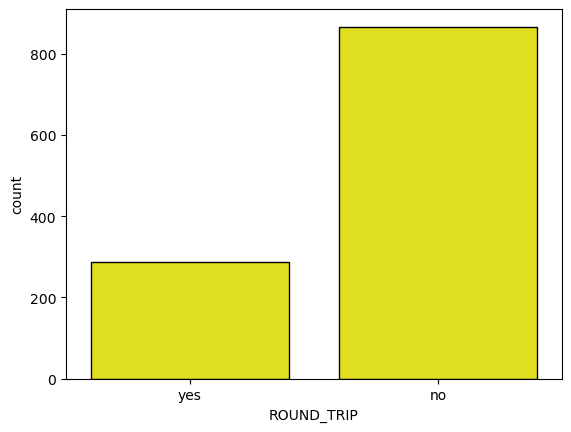

In [213]:
sns.countplot(x=uber_df['ROUND_TRIP'],color='yellow',edgecolor='black')
plt.show()

In [214]:
uber_df['MONTH']=pd.DatetimeIndex(uber_df['START_DATE']).month

In [215]:
uber_df['MONTH']

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
5        1.0
6        1.0
7        1.0
8        1.0
9        1.0
10       1.0
11       1.0
12       1.0
13       1.0
14       1.0
15       1.0
16       1.0
17       1.0
18       1.0
19       1.0
20       1.0
21       1.0
22       1.0
23       NaN
24       NaN
25       NaN
26       NaN
27       NaN
28       NaN
29       NaN
30       NaN
31       NaN
32       NaN
33       NaN
34       NaN
35       NaN
36       NaN
37       NaN
38       NaN
39       NaN
40       NaN
41       NaN
42       NaN
43       NaN
44       NaN
45       NaN
46       NaN
47       NaN
48       NaN
49       NaN
50       NaN
51       NaN
52       NaN
53       NaN
54       NaN
55       NaN
56       NaN
57       NaN
58       NaN
59       NaN
60       NaN
61       2.0
62       2.0
63       2.0
64       2.0
65       2.0
66       2.0
67       2.0
68       2.0
69       2.0
70       2.0
71       2.0
72       2.0
73       2.0
74       2.0
75       2.0
76       2.0

In [216]:
dict = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'July',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

In [217]:
uber_df['MONTH'].map(dict)

0        Jan
1        Jan
2        Jan
3        Jan
4        Jan
5        Jan
6        Jan
7        Jan
8        Jan
9        Jan
10       Jan
11       Jan
12       Jan
13       Jan
14       Jan
15       Jan
16       Jan
17       Jan
18       Jan
19       Jan
20       Jan
21       Jan
22       Jan
23       NaN
24       NaN
25       NaN
26       NaN
27       NaN
28       NaN
29       NaN
30       NaN
31       NaN
32       NaN
33       NaN
34       NaN
35       NaN
36       NaN
37       NaN
38       NaN
39       NaN
40       NaN
41       NaN
42       NaN
43       NaN
44       NaN
45       NaN
46       NaN
47       NaN
48       NaN
49       NaN
50       NaN
51       NaN
52       NaN
53       NaN
54       NaN
55       NaN
56       NaN
57       NaN
58       NaN
59       NaN
60       NaN
61       Feb
62       Feb
63       Feb
64       Feb
65       Feb
66       Feb
67       Feb
68       Feb
69       Feb
70       Feb
71       Feb
72       Feb
73       Feb
74       Feb
75       Feb
76       Feb

In [218]:
uber_df.dropna(subset=['MONTH'],inplace=True)
uber_df['MONTH'].value_counts(dropna=True)

MONTH
11.0    63
8.0     43
3.0     42
6.0     42
7.0     41
2.0     40
12.0    39
5.0     26
4.0     25
10.0    24
1.0     23
9.0     13
Name: count, dtype: int64

In [219]:
uber_df['MONTH'] = uber_df['MONTH'].map(dict)

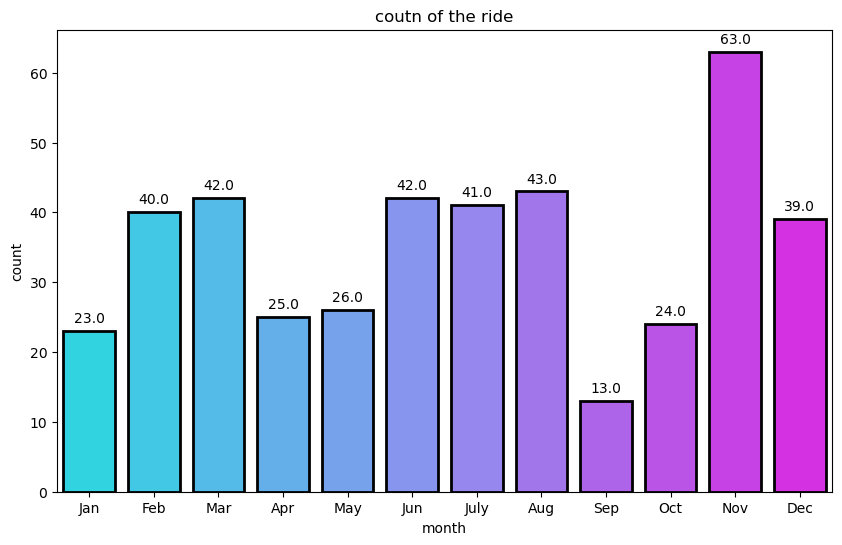

In [220]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=uber_df,x='MONTH',palette='cool',edgecolor='black',linewidth=2)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',(p.get_x() +p.get_width()/2,p.get_height()),ha='center',va='center',xytext=(0,9),textcoords='offset points')
plt.title('coutn of the ride')
plt.xlabel('month')
plt.ylabel('count')
plt.show()


In [221]:
uber_df.groupby(['MONTH','PURPOSE'])['ROUND_TRIP'].count()

MONTH  PURPOSE        
Apr    Customer Visit      5
       Errand/Supplies     3
       Meal/Entertain      5
       Meeting             9
       Not mentioned       3
Aug    Customer Visit      3
       Meal/Entertain      1
       Meeting             1
       Not mentioned      38
Dec    Customer Visit     10
       Errand/Supplies    10
       Meal/Entertain     10
       Meeting             6
       Not mentioned       2
       Temporary Site      1
Feb    Between Offices     1
       Customer Visit      5
       Errand/Supplies     5
       Meal/Entertain     11
       Meeting             8
       Not mentioned       5
       Temporary Site      5
Jan    Customer Visit      3
       Errand/Supplies     4
       Meal/Entertain      6
       Meeting             8
       Not mentioned       1
       Temporary Site      1
July   Customer Visit      1
       Errand/Supplies     4
       Meal/Entertain      2
       Meeting            13
       Not mentioned      19
       Temporary Sit

In [222]:
uber_df['MINUTES']=uber_df['END_DATE'] -uber_df['START_DATE']

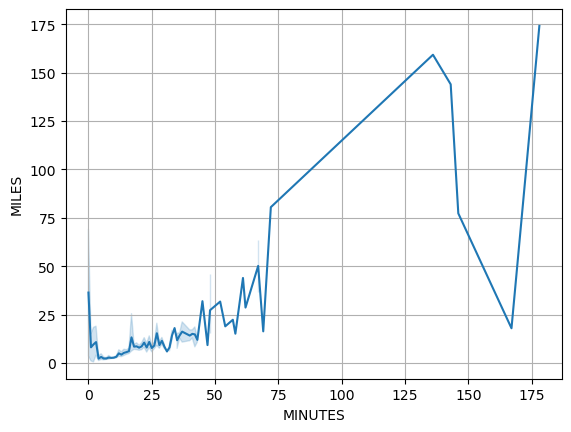

In [223]:
sns.lineplot(data=uber_df, x=uber_df['MINUTES'].dt.total_seconds()/60,y=uber_df['MILES'])
plt.grid(True)
plt.show()

In [224]:
pd.DataFrame({'Min':uber_df.groupby(['PURPOSE'])['MILES'].min(),
              'Mean':uber_df.groupby(['PURPOSE'])['MILES'].mean(),
              'Max':uber_df.groupby(['PURPOSE'])['MILES'].max()})

,Min,Mean,Max
PURPOSE,,,
Between Offices,4.0,10.933333,20.5
Customer Visit,2.4,18.639130,174.2
Errand/Supplies,0.5,4.121277,22.3
Meal/Entertain,1.1,4.912500,17.3
Meeting,0.8,13.822222,159.3
Not mentioned,0.6,7.073750,112.6
Temporary Site,1.9,7.757143,13.5


In [225]:
pd.set_option('display.max_rows',None)##display all the rows 
uber_df.groupby(['MONTH','PURPOSE'])['ROUND_TRIP'].count()

MONTH  PURPOSE        
Apr    Customer Visit      5
       Errand/Supplies     3
       Meal/Entertain      5
       Meeting             9
       Not mentioned       3
Aug    Customer Visit      3
       Meal/Entertain      1
       Meeting             1
       Not mentioned      38
Dec    Customer Visit     10
       Errand/Supplies    10
       Meal/Entertain     10
       Meeting             6
       Not mentioned       2
       Temporary Site      1
Feb    Between Offices     1
       Customer Visit      5
       Errand/Supplies     5
       Meal/Entertain     11
       Meeting             8
       Not mentioned       5
       Temporary Site      5
Jan    Customer Visit      3
       Errand/Supplies     4
       Meal/Entertain      6
       Meeting             8
       Not mentioned       1
       Temporary Site      1
July   Customer Visit      1
       Errand/Supplies     4
       Meal/Entertain      2
       Meeting            13
       Not mentioned      19
       Temporary Sit

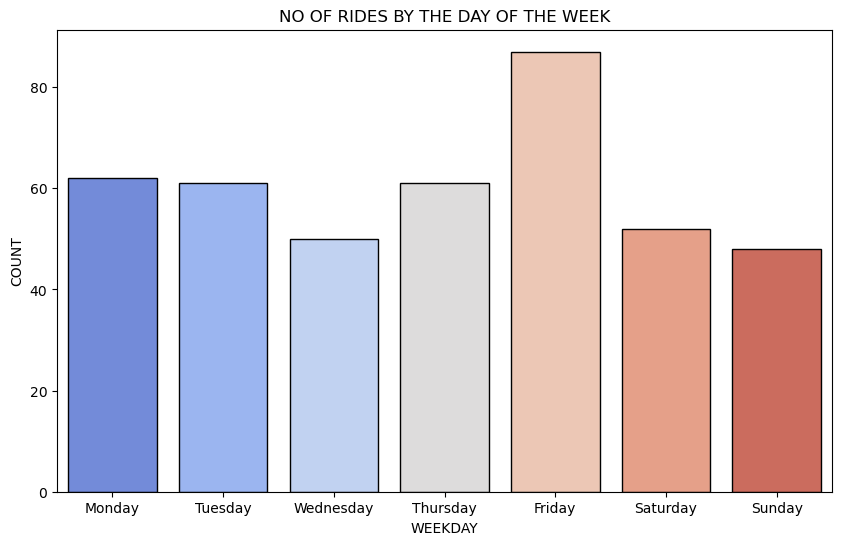

In [226]:
uber_df['WEEKDAY']=uber_df['START_DATE'].dt.day_name()
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x=uber_df['WEEKDAY'], order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],palette='coolwarm',edgecolor='black')
plt.title('NO OF RIDES BY THE DAY OF THE WEEK')
plt.xlabel('WEEKDAY')
plt.ylabel('COUNT')
plt.show()

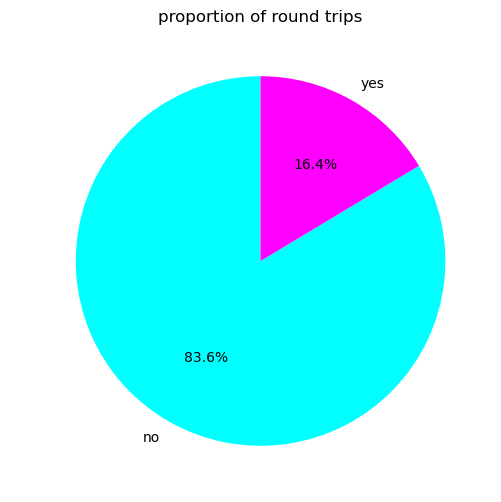

In [227]:
round_trip_counts=uber_df['ROUND_TRIP'].value_counts()
plt.figure(figsize=(10,6))
round_trip_counts.plot(kind='pie',autopct='%1.1f%%', startangle=90,colormap='cool')
plt.title('proportion of round trips')
plt.ylabel(' ')
plt.show()

START
Cary                95
Morrisville         39
Whitebridge         34
Unknown Location    22
Durham              20
Raleigh             11
Westpark Place       8
Apex                 8
Berkeley             7
Kissimmee            6
Name: count, dtype: int64


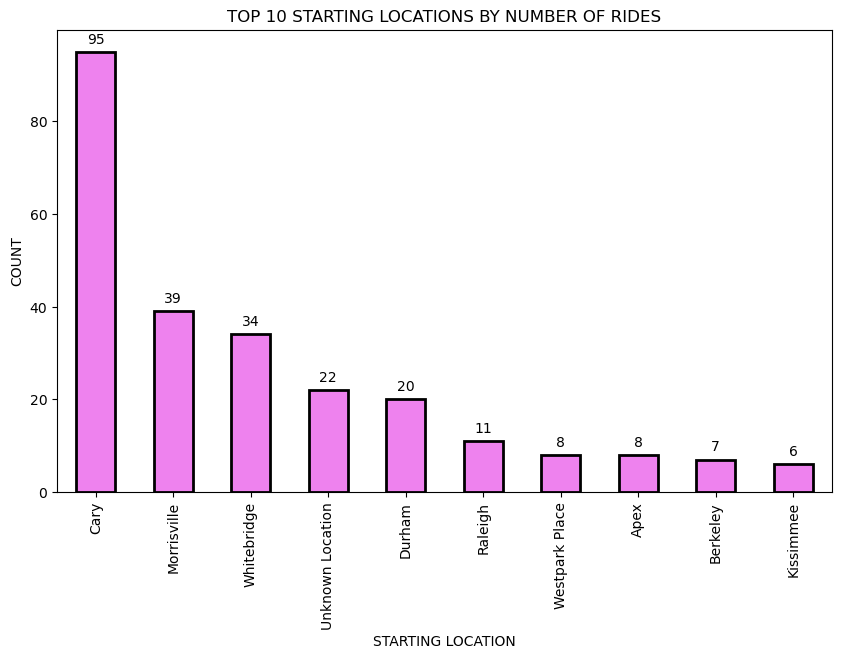

In [228]:
top_start_locations=uber_df['START'].value_counts().head(10)
print(top_start_locations)
plt.figure(figsize=(10,6))
ax=top_start_locations.plot(kind='bar',color='violet',edgecolor='black',linewidth=2)
plt.title('TOP 10 STARTING LOCATIONS BY NUMBER OF RIDES')
plt.xlabel('STARTING LOCATION')
plt.ylabel('COUNT')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',(p.get_x() +p.get_width()/2,p.get_height()),ha='center',va='center',xytext=(0,9),textcoords='offset points')
plt.show()

START
Cary                95
Morrisville         39
Whitebridge         34
Unknown Location    22
Durham              20
Raleigh             11
Westpark Place       8
Apex                 8
Berkeley             7
Kissimmee            6
Name: count, dtype: int64


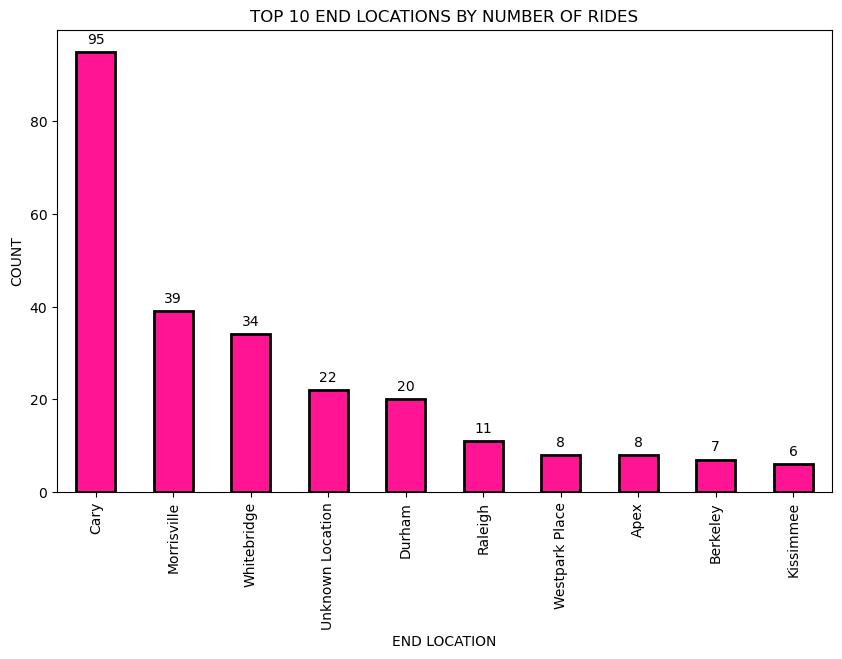

In [229]:
top_end_locations=uber_df['STOP'].value_counts().head(10)
print(top_start_locations)
plt.figure(figsize=(10,6))
ax=top_start_locations.plot(kind='bar',color='deeppink',edgecolor='black',linewidth=2)
plt.title('TOP 10 END LOCATIONS BY NUMBER OF RIDES')
plt.xlabel('END LOCATION')
plt.ylabel('COUNT')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',(p.get_x() +p.get_width()/2,p.get_height()),ha='center',va='center',xytext=(0,9),textcoords='offset points')
plt.show()

In [230]:
uber_df["DAYTIME"] = uber_df["DAYTIME"].astype(str)
base_fare = 2.00
rate_per_mile=5.00
time_fare= {
    "Morning": 1.00,
    "Afternoon": 2.00,
    "Evening": 2.50,
    "Night": 1.00
}
uber_df["Fare_Multiplier"] = uber_df["DAYTIME"].map(time_fare)
uber_df["Estimated_Fare"] = np.where(
    uber_df["ROUND_TRIP"] == "yes",
    ((base_fare + uber_df["MILES"] * rate_per_mile) * uber_df["Fare_Multiplier"]) * 2,
    (base_fare + uber_df["MILES"] * rate_per_mile) * uber_df["Fare_Multiplier"]
)
uber_df["Estimated_Fare"] = uber_df["Estimated_Fare"].round(2)

In [231]:
print(uber_df["DAYTIME"].dtype)
print(uber_df["DAYTIME"].head())

object
0        Night
1      Morning
2        Night
3      Evening
4    Afternoon
Name: DAYTIME, dtype: object


In [232]:
uber_df["DAYTIME"] = uber_df["DAYTIME"].astype(str)

In [233]:
uber_df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAYTIME,ROUND_TRIP,MONTH,MINUTES,WEEKDAY,Fare_Multiplier,Estimated_Fare
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,Night,yes,Jan,0 days 00:06:00,Friday,1.0,55.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not mentioned,2016-01-02,1.0,Morning,yes,Jan,0 days 00:12:00,Saturday,1.0,54.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,Night,yes,Jan,0 days 00:13:00,Saturday,1.0,52.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,Evening,yes,Jan,0 days 00:14:00,Tuesday,2.5,127.5
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,Afternoon,no,Jan,0 days 01:07:00,Wednesday,2.0,641.0


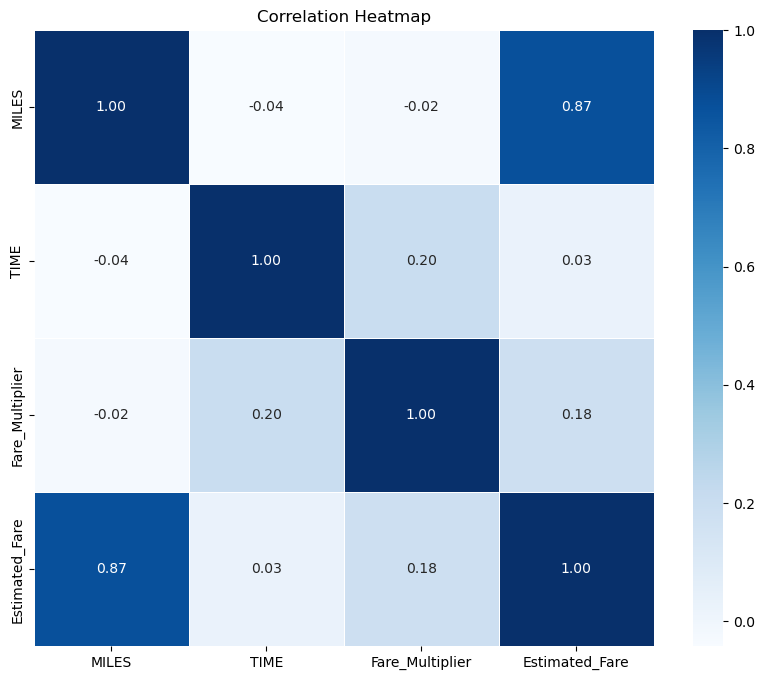

In [234]:
plt.figure(figsize=(10,8))

sns.heatmap(uber_df.corr(numeric_only=True),
            annot=True,
            cmap='Blues',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

In [235]:
uber_df['DAYTIME']=uber_df['DAYTIME'].map({'Morning':1,'Afternoon':2,'Evening':3,'Night':4})
uber_df['ROUND_TRIP']=uber_df['ROUND_TRIP'].map({'yes':1,'no':0})

In [236]:
uber_df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAYTIME,ROUND_TRIP,MONTH,MINUTES,WEEKDAY,Fare_Multiplier,Estimated_Fare
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,4,1,Jan,0 days 00:06:00,Friday,1.0,55.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not mentioned,2016-01-02,1.0,1,1,Jan,0 days 00:12:00,Saturday,1.0,54.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,4,1,Jan,0 days 00:13:00,Saturday,1.0,52.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,3,1,Jan,0 days 00:14:00,Tuesday,2.5,127.5
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,2,0,Jan,0 days 01:07:00,Wednesday,2.0,641.0


In [237]:
data_x= uber_df[["MILES", "DAYTIME", "ROUND_TRIP","Fare_Multiplier"]]

In [238]:
data_x.head()

,MILES,DAYTIME,ROUND_TRIP,Fare_Multiplier
0,5.1,4,1,1.0
1,5.0,1,1,1.0
2,4.8,4,1,1.0
3,4.7,3,1,2.5
4,63.7,2,0,2.0


In [239]:
data_y=uber_df['Estimated_Fare']
data_y.head()

0     55.0
1     54.0
2     52.0
3    127.5
4    641.0
Name: Estimated_Fare, dtype: float64

In [240]:
from sklearn.model_selection import train_test_split  
data_x_train, data_x_test, data_y_train, data_y_test = train_test_split(
    data_x, 
    data_y, 
    test_size=0.2, 
    random_state=42  
)
    

In [241]:
len(data_x_train),len(data_x_test)

(336, 85)

In [242]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
lr = LinearRegression()
lr.fit(data_x_train, data_y_train)
data_y_pred=lr.predict(data_x_test)
mae = mean_absolute_error(data_y_test, data_y_pred)
mse = mean_squared_error(data_y_test, data_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(data_y_test,data_y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R^2 Score :", r2)
print("Score:", lr.score(data_x_test, data_y_test))


MAE : 29.51148655345658
MSE : 5382.755582172924
RMSE : 73.36726505855948
R^2 Score : 0.9060922812825573
Score: 0.9060922812825573


In [243]:
print(data_x.isnull().sum())
print(data_y.isnull().sum())

MILES              0
DAYTIME            0
ROUND_TRIP         0
Fare_Multiplier    0
dtype: int64
0


In [244]:
data_x.dtypes

MILES              float64
DAYTIME              int64
ROUND_TRIP           int64
Fare_Multiplier    float64
dtype: object

In [245]:
print(lr.score(data_x_test, data_y_test))

0.9060922812825573


In [246]:
comparison = pd.DataFrame({
    "Actual": data_y_test,
    "Predicted":data_y_pred
})

print(comparison.head(20))

      Actual   Predicted
358    74.00   78.866371
903    17.50  -11.056713
411    54.00   52.793510
938    29.00   34.767649
1044   48.00   51.386201
186   113.00  108.239138
345    82.50   98.608628
350    14.50  -16.304676
68     50.50   37.757324
185   108.00  103.865835
183    51.50   39.506645
207    44.00   26.386736
937    44.00   47.887558
203   123.00  116.985744
895   111.25  118.725822
1040   42.50   70.619490
9     169.00  157.220131
620    44.00   26.386736
432    23.50   -0.560786
533    44.50   27.261397


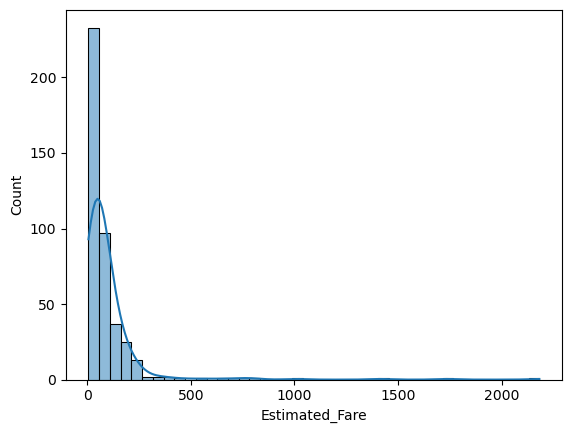

In [247]:
sns.histplot(data_y, kde=True)
plt.show()

In [248]:
print(uber_df["Estimated_Fare"].describe())

count     421.000000
mean       95.384798
std       178.921960
min         6.000000
25%        28.750000
50%        51.500000
75%       103.000000
max      2182.500000
Name: Estimated_Fare, dtype: float64


MAE : 26.476470588235294
MSE : 25012.332352941175
RMSE : 158.15287652439704
R^2 Score : 0.5636340838424243
Score: 0.5636340838424243
      Actual  Predicted
358    74.00      74.50
903    17.50      17.50
411    54.00      54.00
938    29.00      29.00
1044   48.00      48.00
186   113.00     112.00
345    82.50      82.50
350    14.50      14.00
68     50.50      51.50
185   108.00     108.00
183    51.50      51.50
207    44.00      43.50
937    44.00      44.00
203   123.00     122.00
895   111.25     113.75
1040   42.50      42.50
9     169.00     169.00
620    44.00      43.50
432    23.50      24.50
533    44.50      45.00


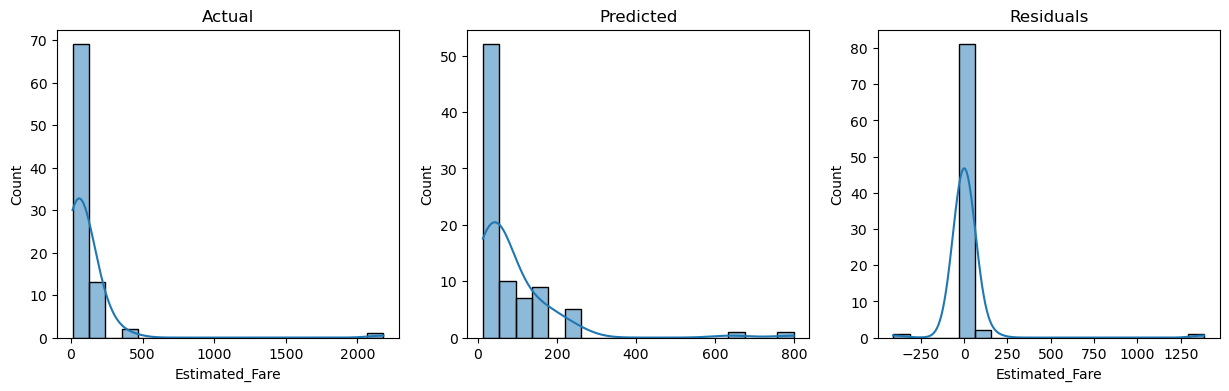

In [268]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(data_x_train, data_y_train)
data_y_pred=dt.predict(data_x_test)
mae = mean_absolute_error(data_y_test, data_y_pred)
mse = mean_squared_error(data_y_test, data_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(data_y_test,data_y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R^2 Score :", r2)
print("Score:", dt.score(data_x_test, data_y_test))
comparison = pd.DataFrame({
    "Actual": data_y_test,
    "Predicted":data_y_pred
})

print(comparison.head(20))
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(data_y_test, kde=True, ax=axes[0]).set_title('Actual')
sns.histplot(data_y_pred, kde=True, ax=axes[1]).set_title('Predicted')
sns.histplot(data_y_test - data_y_pred, kde=True, ax=axes[2]).set_title('Residuals')
plt.show()

MAE : 19.52764705882353
MSE : 12155.754012647061
RMSE : 110.25313606717526
R^2 Score : 0.7879303432616059
Score: 0.7879303432616059
      Actual  Predicted
358    74.00    75.7100
903    17.50    17.4850
411    54.00    53.9900
938    29.00    28.8825
1044   48.00    48.0900
186   113.00   114.1400
345    82.50    82.3250
350    14.50    14.3200
68     50.50    53.7550
185   108.00   108.0400
183    51.50    51.2300
207    44.00    43.8100
937    44.00    44.6950
203   123.00   121.8875
895   111.25   110.7925
1040   42.50    42.3000
9     169.00   170.1175
620    44.00    43.8100
432    23.50    24.2300
533    44.50    45.0100


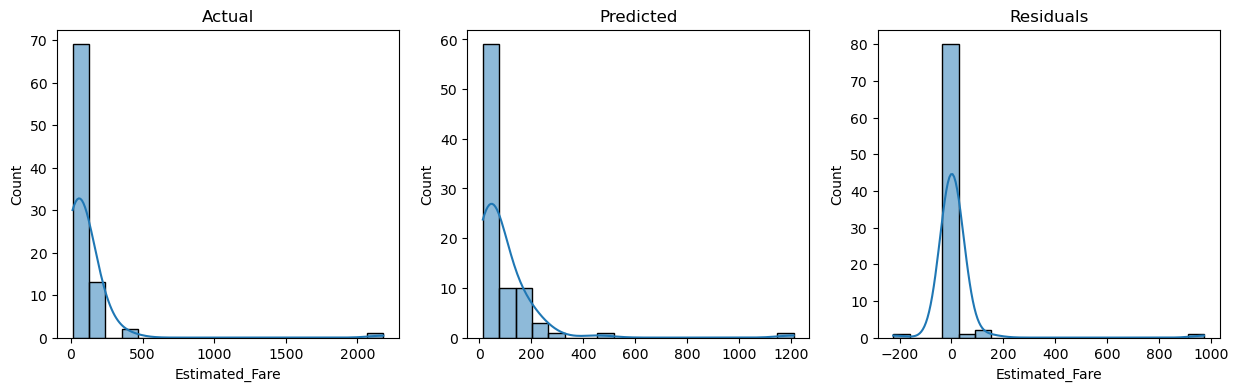

In [264]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(data_x_train, data_y_train)
data_y_pred=rf.predict(data_x_test)
mae = mean_absolute_error(data_y_test, data_y_pred)
mse = mean_squared_error(data_y_test, data_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(data_y_test,data_y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R^2 Score :", r2)
print("Score:", rf.score(data_x_test, data_y_test))
comparison = pd.DataFrame({
    "Actual": data_y_test,
    "Predicted":data_y_pred
})

print(comparison.head(20))
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(data_y_test, kde=True, ax=axes[0]).set_title('Actual')
sns.histplot(data_y_pred, kde=True, ax=axes[1]).set_title('Predicted')
sns.histplot(data_y_test - data_y_pred, kde=True, ax=axes[2]).set_title('Residuals')
plt.show()

MAE : 26.072941176470586
MSE : 19133.389941176476
RMSE : 138.323497429672
R^2 Score : 0.6661982931831686
Score: 0.6661982931831686
      Actual  Predicted
358    74.00     102.70
903    17.50      17.30
411    54.00      53.80
938    29.00      27.80
1044   48.00      48.00
186   113.00     112.60
345    82.50      81.75
350    14.50      15.80
68     50.50      47.70
185   108.00     109.00
183    51.50      47.70
207    44.00      42.80
937    44.00      43.00
203   123.00     120.80
895   111.25     109.00
1040   42.50      41.75
9     169.00     166.80
620    44.00      42.80
432    23.50      24.20
533    44.50      44.80


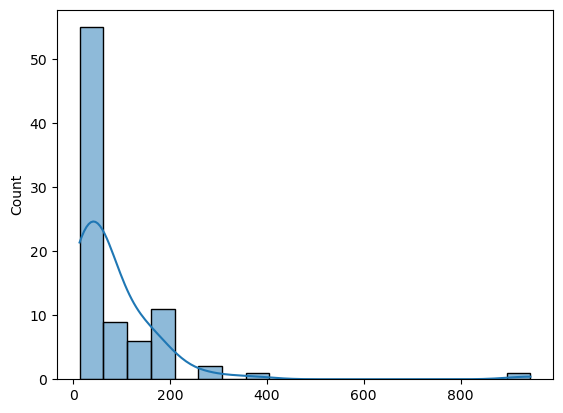

In [276]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(data_x_train, data_y_train)
data_y_pred=knn.predict(data_x_test)
mae = mean_absolute_error(data_y_test, data_y_pred)
mse = mean_squared_error(data_y_test, data_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(data_y_test,data_y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R^2 Score :", r2)
print("Score:", knn.score(data_x_test, data_y_test))
comparison = pd.DataFrame({
    "Actual": data_y_test,
    "Predicted":data_y_pred
})

print(comparison.head(20))
sns.histplot(x=data_y_pred,kde=True)
plt.show()

In [277]:
print(uber_df["ROUND_TRIP"].unique())

[1 0]


In [278]:
print(uber_df["ROUND_TRIP"].unique())

[1 0]


In [279]:
print(time_fare)

{'Morning': 1.0, 'Afternoon': 2.0, 'Evening': 2.5, 'Night': 1.0}


In [280]:
uber_df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,DAYTIME,ROUND_TRIP,MONTH,MINUTES,WEEKDAY,Fare_Multiplier,Estimated_Fare
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,4,1,Jan,0 days 00:06:00,Friday,1.0,55.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not mentioned,2016-01-02,1.0,1,1,Jan,0 days 00:12:00,Saturday,1.0,54.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,4,1,Jan,0 days 00:13:00,Saturday,1.0,52.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,3,1,Jan,0 days 00:14:00,Tuesday,2.5,127.5
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,2,0,Jan,0 days 01:07:00,Wednesday,2.0,641.0


In [287]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Generate new/unseen rides — values not in your training set
np.random.seed(123)  # different seed = different data than train_test_split used
n_unseen = 50

unseen_df = pd.DataFrame({
    "MILES": np.round(np.random.uniform(0.5, 30, n_unseen), 2),
    "DAYTIME": np.random.choice([1, 2, 3, 4], n_unseen),   # 1=Morning,2=Afternoon,3=Evening,4=Night
    "ROUND_TRIP": np.random.choice([0, 1], n_unseen)
})

# 2. Recreate Fare_Multiplier exactly as you did for training
time_fare = {1: 1.00, 2: 2.00, 3: 2.50, 4: 1.00}
unseen_df["Fare_Multiplier"] = unseen_df["DAYTIME"].map(time_fare)

# 3. Compute the TRUE fare using your original formula (this is the "actual" ground truth)
base_fare = 2.00
rate_per_mile = 5.00
unseen_df["Actual_Fare"] = np.where(
    unseen_df["ROUND_TRIP"] == 1,
    ((base_fare + unseen_df["MILES"] * rate_per_mile) * unseen_df["Fare_Multiplier"]) * 2,
    (base_fare + unseen_df["MILES"] * rate_per_mile) * unseen_df["Fare_Multiplier"]
)

# 4. Prepare features in the SAME column order as training
unseen_x = unseen_df[["MILES", "DAYTIME", "ROUND_TRIP", "Fare_Multiplier"]]
unseen_y_actual = unseen_df["Actual_Fare"]

# 5. Test each trained model on this unseen data
models = {"Linear Regression": lr, "Decision Tree": dt, "Random Forest": rf, "KNN": knn}

for name, model in models.items():
    pred = model.predict(unseen_x)
    mae = mean_absolute_error(unseen_y_actual, pred)
    rmse = np.sqrt(mean_squared_error(unseen_y_actual, pred))
    r2 = r2_score(unseen_y_actual, pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R^2: {r2:.4f}")

# 6. Compare actual vs predicted for the best model, e.g. Random Forest
unseen_df["Predicted_Fare"] = rf.predict(unseen_x)
print(unseen_df[["MILES","DAYTIME","ROUND_TRIP","Actual_Fare","Predicted_Fare"]].head(10))

Linear Regression -> MAE: 38.14, RMSE: 71.64, R^2: 0.6726
Decision Tree -> MAE: 26.60, RMSE: 49.55, R^2: 0.8434
Random Forest -> MAE: 24.53, RMSE: 52.37, R^2: 0.8251
KNN -> MAE: 53.57, RMSE: 96.66, R^2: 0.4040
   MILES  DAYTIME  ROUND_TRIP  Actual_Fare  Predicted_Fare
0  21.05        2           0      214.500        212.8325
1   8.94        1           1       93.400         85.9250
2   7.19        3           0       94.875         92.0325
3  16.76        2           1      343.200        327.8850
4  21.72        2           0      221.200        218.8575
5  12.98        4           0       66.900         67.8750
6  29.43        1           1      298.300        275.7250
7  20.70        2           1      422.000        316.9850
8  14.69        2           0      150.900        154.9400
9  12.07        1           1      124.700        130.7800


In [288]:
unseen_df["Predicted_Fare"] = dt.predict(unseen_x)
print(unseen_df[["MILES","DAYTIME","ROUND_TRIP","Actual_Fare","Predicted_Fare"]].head(10))

   MILES  DAYTIME  ROUND_TRIP  Actual_Fare  Predicted_Fare
0  21.05        2           0      214.500          209.00
1   8.94        1           1       93.400           90.00
2   7.19        3           0       94.875           93.75
3  16.76        2           1      343.200          310.00
4  21.72        2           0      221.200          227.00
5  12.98        4           0       66.900           67.00
6  29.43        1           1      298.300          290.00
7  20.70        2           1      422.000          310.00
8  14.69        2           0      150.900          153.00
9  12.07        1           1      124.700          228.00
